# Convex Hull Construction
The paper [Shahriar and Rahman (2013)](Shahriar%20and%20Rahman%20-%202013%20-%20Spatial-temporal%20prediction%20of%20algal%20bloom.pdf) explores a method to predict the motion of Harmful Algal Blooms (HABs) using a method where they construct a [convex hull](https://en.wikipedia.org/wiki/Convex_hull) around an existing group of algae (based up on measurements).


The goal of this notebook is to provide a simplified example of constructing this convex hull, mainly to explore the functions that Julia has available for constructing convex hulls.

We are using [`Meshes.jl`](https://juliageometry.github.io/MeshesDocs/stable/index.html) to provide the convex hull functionality.

In [27]:
# Imports
using Meshes, CairoMakie, Random, Unitful
import Meshes: Point, convexhull, centroid, rings, segments

In [2]:
# Generate random 2D Meshes.jl points
# (Meshes uses a uniform Point(x, y) syntax rather than Point2f)
Random.seed!(42) # Optional: for reproducibility
raw_pts = [Meshes.Point(rand(), rand()) for _ in 1:100]
pts = PointSet(raw_pts)

100 PointSet
├─ Point(x: 0.6293451231426089 m, y: 0.4503389405961936 m)
├─ Point(x: 0.47740714343281776 m, y: 0.7031298490032014 m)
├─ Point(x: 0.6733461456394962 m, y: 0.16589443479313404 m)
├─ Point(x: 0.6134782250008441 m, y: 0.6683403279577278 m)
├─ Point(x: 0.4570310908017041 m, y: 0.2993652953937611 m)
⋮
├─ Point(x: 0.5205236039814605 m, y: 0.14330265538830045 m)
├─ Point(x: 0.00428093579279476 m, y: 0.4845814872066476 m)
├─ Point(x: 0.3318565899720589 m, y: 0.7231159718859554 m)
├─ Point(x: 0.11857619277923426 m, y: 0.20522551477456907 m)
└─ Point(x: 0.9076140923255073 m, y: 0.449259487025214 m)

In [3]:
# Construct the convex hull
hull = convexhull(pts)


PolyArea
  outer
  └─ Ring((x: 0.00428094 m, y: 0.484581 m), ..., (x: 0.00441704 m, y: 0.793353 m))

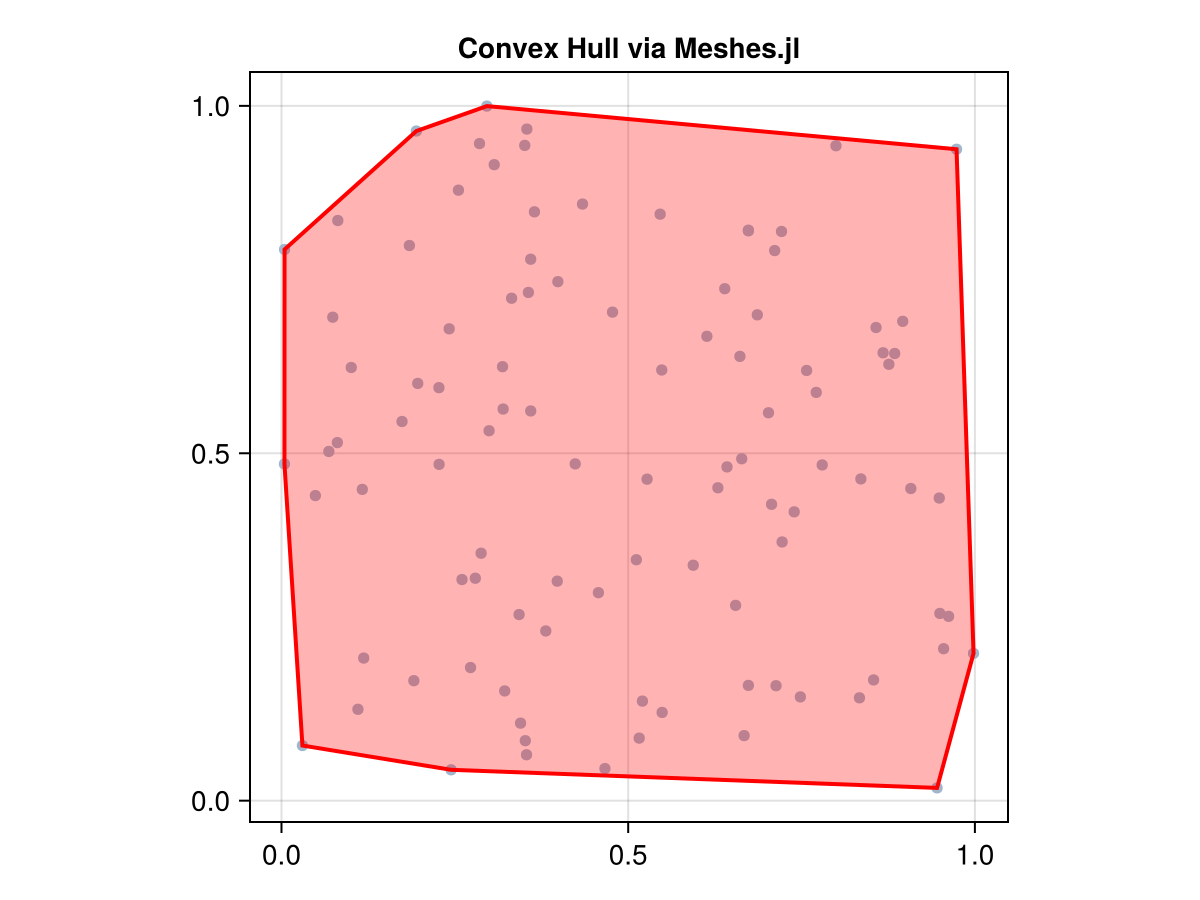

In [41]:
# Plot the figure
fig = Figure()
ax = Axis(fig[1, 1], title = "Convex Hull via Meshes.jl", aspect = DataAspect())

# 4. Use the specific segment properties allowed by the recipe
viz!(ax, pts, pointcolor = :black, pointsize = 8)
viz!(ax, hull, color = :red, alpha = 0.3, showsegments = true, segmentcolor = :red, segmentsize = 2)

fig

# Compressing convex hull into radii-based vector
In the paper above, they take the computed convex hull and represent it as a compressed vector with the centroid and $n$ radii representing the points of the boundary alongs various directions from the centroid.

We define a 38-element vector: the first two elements being the coordinates of the centroid, and each remaining element the radius at 10 degree increments from 0 (0 being North)

In [42]:
# Compute the Hull Centroid
c = centroid(hull)
cx = ustrip(c.coords.x);
cy = ustrip(c.coords.y);

c # print centroid coordinates

Point with Cartesian{NoDatum} coordinates
├─ x: 0.41013942841915924 m
└─ y: 0.5036720695927779 m

In [43]:
# Extract the boundary edges as segments to intersect against
outer_boundary = first(rings(hull))
hull_segments = segments(outer_boundary)

Base.Generator{UnitRange{Int64}, Meshes.var"#segments##0#segments##1"{CircularArrays.CircularVector{Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}, Vector{Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}}}}}(Meshes.var"#segments##0#segments##1"{CircularArrays.CircularVector{Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}, Vector{Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}}}}(Point{𝔼{2}, CoordRefSystems.Cartesian2D{CoordRefSystems.NoDatum, Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}}[Point(x: 0.00428093579279476 m, y: 0.4845814872066476 m), Point(x: 0.030185550039208087 m, y: 0.07933388944734077 m), Point(x: 0.24462184800247666 m, y: 0.044385887200565466 m), Point(x

In [44]:
# 3. Define 36 angles in degrees (0 = North/Up, moving clockwise)
angles_deg = 0:10:350

# Track the computed radii
radii = Float64[]

# Use a large bounding length to ensure ray segments fully exit the hull
max_radius = 2.0 

radii = Float64[]
visual_rays = Segment[]  # Storing the actual boundary-hitting segments

for deg in angles_deg
    rad = deg2rad(deg)
    dx, dy = sin(rad), cos(rad)
    
    target_point = Point(cx + max_radius * dx, cy + max_radius * dy)
    ray_segment = Segment(c, target_point)
    
    r_length = 0.0
    for edge in hull_segments
        intersect_result = ray_segment ∩ edge
        if intersect_result isa Point
            r_length = Float64(ustrip(Meshes.length(Segment(c, intersect_result))))
            
            # Save the truncated segment for plotting
            push!(visual_rays, Segment(c, intersect_result))
            break
        end
    end
    push!(radii, r_length)
end

compressed_vector = vcat([cx, cy], radii)

38-element Vector{Float64}:
 0.41013942841915924
 0.5036720695927779
 0.4855602079367374
 0.485203357327916
 0.5000290014139941
 0.5324782360705143
 0.5885553151943118
 0.6809601558872023
 0.6547189039622083
 0.6076883970637325
 ⋮
 0.4058500773468085
 0.41207893959171427
 0.4318273484778757
 0.46851606521243455
 0.49145844597372246
 0.4867972941582664
 0.497188620139867
 0.5056923280346779
 0.5011561678596654

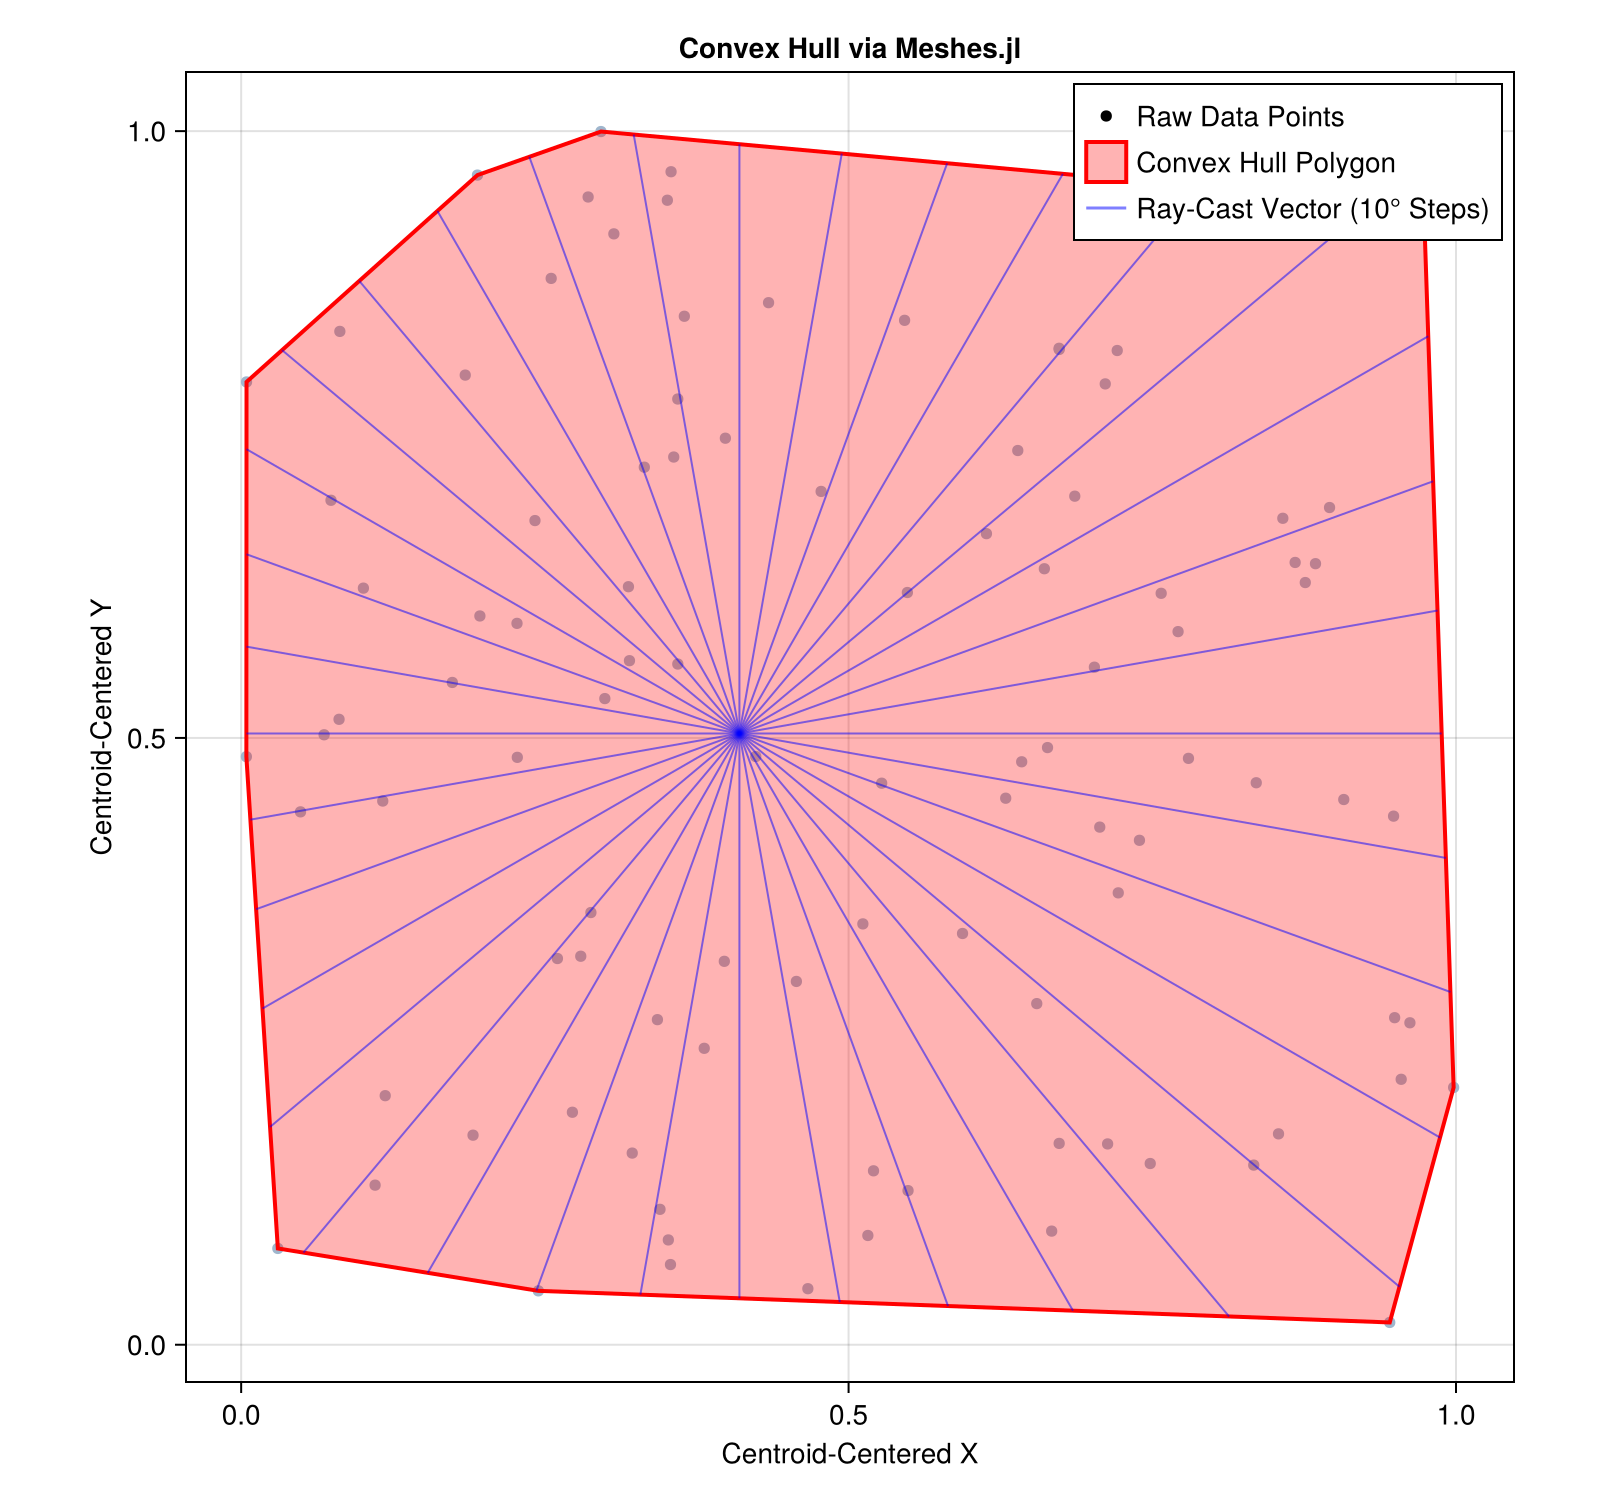

In [46]:
fig = Figure(size = (800, 750))
ax = Axis(fig[1, 1], title = "Convex Hull via Meshes.jl", aspect = DataAspect(),
          xlabel = "Centroid-Centered X", ylabel = "Centroid-Centered Y")

# 1. Plot the elements using your specific properties
viz!(ax, pts, pointcolor = :black, pointsize = 8)
viz!(ax, hull, color = :red, alpha = 0.3, showsegments = true, segmentcolor = :red, segmentsize = 2)
viz!(ax, GeometrySet(visual_rays), color = :blue, alpha = 0.5, segmentsize = 1)

# 2. Build explicit legend elements matching your visual configurations
elem_pts  = MarkerElement(color = :black, marker = :circle, markersize = 8)
elem_hull = PolyElement(color = (:red, 0.3), strokecolor = :red, strokewidth = 2)
elem_rays = LineElement(color = (:blue, 0.5), linewidth = 1.5)

# 3. Add the manual legend
axislegend(ax, 
    [elem_pts, elem_hull, elem_rays], 
    ["Raw Data Points", "Convex Hull Polygon", "Ray-Cast Vector (10° Steps)"],
    position = :rt
)

fig